# Hands-on tutorial on programming SNNs with snnTorch

**Tutorial by Anurag Daram**

                                                                                

[Neuromorphic Artificial Intelligence Lab](https://nuailab.com/) @ UTSA


Things you'll learn in this session:

+ To train and evaluate a simple spiking neural network (SNN)
+ Understand the basics of SNNs
    + Spike-encoding mechanisms
    + The simple leaky-integrate and fire neuron
    + Setting up and training feedforward spiking neural networks





This tutorial is based on code from this repository: https://github.com/jeshraghian/snntorch.

Other popular libraries for modelling SNNs are [PyNN](https://neuralensemble.org/PyNN/), [Lava](https://github.com/lava-nc/lava) and [Fugu](https://github.com/sandialabs/Fugu).


## Setup
For this tutorial we will use [PyTorch](https://pytorch.org/) as our main deep learning library, [snnTorch](https://snntorch.readthedocs.io/en/latest/) for spiking networks, and the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) to generate evaluation scenarios and train the network.

If you want to play around, make a **copy** of this notebook. (you would need a gmail account for this)

**File -> Save a copy in drive**. Then open the copy and feel free to make any edits to that version.

Make sure you are also connected to a runtime (on the top right of the page}

We will have multiple code blocks in this tutorial. **Make sure to execute the code blocks one after the other**(even if few code blocks are hidden). You can execute the cell by clicking the play symbol next to the cell.
Also, you can create a copy of this file and run separately if you want to make changes and play around

Now that we are done with the basics and summary,

---

lets get our hands dirty and start the adventure towards understanding spiking neural networks

<img src="https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExNWFyNjBsZ2xuNTE5azV1ZzVmdjNzM244dXpwdTQ5dWQ2YXA3dXkyYiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/zHh9VuhWZ99qrUSIlo/giphy.gif"  />


## What are SNNs?
Spiking Neural Networks (SNNs) represent a novel approach in artificial neural networks, inspired by the biological processes of the human brain. Unlike traditional artificial neural networks (ANNs) that rely on continuous signal processing, SNNs operate on discrete events called "spikes."

The human brain consists of approximately 86 billion neurons, which communicate through electrical impulses known as action potentials or spikes. This communication method is energy-efficient and highly effective for processing information. SNNs aim to replicate this spiking behavior, leveraging the brain's mechanisms for computation and learning.


The tutorial will be thereby divided into multiple parts:
1. Spike encoding with snnTorch
2. Understanding the Leaky-Integrate and Fire neuron
3. Building and training a feedforward SNN on MNIST



## Spike Encoding with snnTorch

Light is what we see when the retina converts photons into spikes. Odors are what we smell when volatilised molecules are converted into spikes. Touch is what we feel when nerve endings turn tactile pressure into spikes. The brain trades in the global currency of the spike.

If our end goal is to build a spiking neural network (SNN), it makes sense to use spikes at the input too. Although, it is quite common to use non-spiking inputs, using spikes comes along with a lot of benefits such as sparsity and event driven processing (static-suppression).


<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial1/3s.png?raw=true' width="600">
</center>



In this tutorial, we will assume we have some non-spiking input data (i.e., the MNIST dataset) and we want to encode it into spikes using a few different techniques. So let's get started!

#### Lets begin with some package installation

In [ ]:
!pip install snntorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 1.2 MB/s eta 0:00:0000:010:01


If you had any issues with installing, let me know. Luckily a lot of packages come pre installed in colab, so we just have this library to install. I promise.

#### Load Libraries

In [3]:
import snntorch as snn
import torch
from torchvision import datasets, transforms


In [ ]:
# Training Parameters
batch_size=128
data_path='/tmp/data/mnist'
num_classes = 10  # MNIST has 10 output classes

# Torch Variables
dtype = torch.float

#### Download the MNIST dataset

In [ ]:

# Define a transform
transform = transforms.Compose([
            transforms.Resize((28,28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]


Extracting /tmp/data/mnist/MNIST/raw/train-images-idx3-ubyte.gz to /tmp/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]


Extracting /tmp/data/mnist/MNIST/raw/train-labels-idx1-ubyte.gz to /tmp/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.39MB/s]


Extracting /tmp/data/mnist/MNIST/raw/t10k-images-idx3-ubyte.gz to /tmp/data/mnist/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.94MB/s]


Extracting /tmp/data/mnist/MNIST/raw/t10k-labels-idx1-ubyte.gz to /tmp/data/mnist/MNIST/raw



While executing the above block, an error `Failed to download (trying next): HTTP Error 403: Forbidden` might appear but pytorch finds other sources to download from and it should work without any issues.


We will start using some utils functions to perform our tasks for now.

Until we actually start training a network, we won't need large datasets. snntorch.utils contains a few useful functions for modifying datasets. Apply `data_subset` to reduce the dataset by the factor defined in subset. E.g., for subset=10, a training set of 60,000 will be reduced to 6,000.

In [ ]:
from snntorch import utils

subset = 10
mnist_train = utils.data_subset(mnist_train, subset)
print(f"The size of mnist_train is {len(mnist_train)}")

The size of mnist_train is 6000


#### Load the dataset

First, create the dataloaders to read the input dataset.

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

### Understanding Encoding mechanisms

Spiking Neural Networks (SNNs) are made to exploit time-varying data. And yet, MNIST is not a time-varying dataset.
There are two ways of using MNIST with an SNN:

1. Repeatedly pass the same training sample $\mathbf{X}\in\mathbb{R}^{m\times n}$ to the network at each time step. This is like converting MNIST into a static, unchanging video. Each element of $\mathbf{X}$ can take a high precision value normalized between 0 and 1: $X_{ij}\in [0, 1]$.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial1/1_2_1_static.png?raw=true' width="700">
</center>

2. Convert the input into a spike train of sequence length `num_steps`, where each feature/pixel takes on a discrete value $X_{i,j} \in \{0, 1\}$.
In this case, MNIST is converted into a time-varying sequence of spikes that features a relation to the original image.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial1/1_2_2_spikeinput.png?raw=true' width="700">
</center>

The first method is quite straightforward, and does not fully exploit the temporal dynamics of SNNs. So let’s consider data-to-spike conversion (encoding) from the second option in more detail.

We will use the `snntorch.spikegen` (i.e., spike generation) function to simplify the conversion of data into spikes. There are currently three options available for spike encoding in `snntorch`:

1. Rate coding: [`spikegen.rate`](https://snntorch.readthedocs.io/en/latest/snntorch.spikegen.html#snntorch.spikegen.rate)
2. Latency coding: [`spikegen.latency`](https://snntorch.readthedocs.io/en/latest/snntorch.spikegen.html#snntorch.spikegen.latency)
3. Delta modulation: [`spikegen.delta`](https://snntorch.readthedocs.io/en/latest/snntorch.spikegen.html#snntorch.spikegen.delta)

How do these differ?


1.   *Rate coding* uses input features to determine spiking **frequency**
2.   *Latency coding* uses input features to determine spike **timing**
3.   *Delta modulation* uses the temporal **change** of input features to generate spikes


In this tutorial, we will focus primarily on the rate encoding method



#### **Rate coding of MNIST**

One example of converting input data into a rate code is as follows.
Each normalised input feature $X_{ij}$ is used as the probability an event (spike) occurs at any given time step, returning a rate-coded value $R_{ij}$. This can be treated as a Bernoulli trial: $R_{ij}\sim B(n,p)$, where the number of trials is $n=1$, and the probability of success (spiking) is $p=X_{ij}$. Explicitly, the probability a spike occurs is:

$${\rm P}(R_{ij}=1) = X_{ij} = 1 - {\rm P}(R_{ij} = 0)$$

Create a vector filled with the value '0.5' and encode it using the above technique:

The other option is to use a Poisson encoding scheme, wherein each value of the pixel can represent a frequency at which a input spike train would spike for a given time interval.

In [5]:
# Temporal Dynamics
num_steps = 100

# create vector filled with 0.5
raw_vector = torch.ones(num_steps)*0.5

# pass each sample through a Bernoulli trial
rate_coded_vector = torch.bernoulli(raw_vector)
print(f"Converted vector: {rate_coded_vector}")

print(f"The output is spiking {rate_coded_vector.sum()*100/len(rate_coded_vector):.2f}% of the time.")

## Task try playing with the vector size (defined by the num_steps) variable and see how it affects the spiking activity

Converted vector: tensor([1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1.,
        1., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1., 1., 0.,
        1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1.,
        0., 1., 0., 0., 1., 0., 1., 1., 0., 0.])
The output is spiking 57.00% of the time.




```
# This is formatted as code
```

For an MNIST image, this probability of spiking corresponds to the pixel value. A white pixel corresponds to a 100% probability of spiking, and a black pixel will never generate a spike. Take a look at the 'Rate Coding' column below for further intuition.


<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial1/1_2_3_spikeconv.png?raw=true' width="1000">
</center>

Now, we can apply the same to the MNIST dataset. Lets convert the MNIST dataset to these binary vectors.

In [6]:
from snntorch import spikegen

# Iterate through minibatches
data = iter(train_loader)
data_it, targets_it = next(data)

# Spiking Data
spike_data = spikegen.rate(data_it, num_steps=num_steps)

NameError: name 'train_loader' is not defined

In [7]:
print(spike_data.size())  ## Dimension is represented by [#num_steps x batch_size x input_dimensions]

NameError: name 'spike_data' is not defined

### Visualizations

Just looking at code and numbers might be boring, so what should we do.

**Write more code** 😠

<img src="https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExNGpwNmt3c293bWMzNmZzZW1sa2JmYTkzZzZneXd1Z2puc2xlN2xwOCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3o85xGr7NxBC4eGTte/giphy.gif" >


Its just a little bit, enough to create some visualizations. Bear with me please.

Luckily for us, snnTorch contains a module [`snntorch.spikeplot`](https://snntorch.readthedocs.io/en/latest/snntorch.spikeplot.html) that simplifies the process of visualizing, plotting, and animating spiking neurons.


In [ ]:
import matplotlib.pyplot as plt
import snntorch.spikeplot as splt
from IPython.display import HTML

In [ ]:
spike_data_sample = spike_data[:, 0, 0]
print(spike_data_sample.size())

torch.Size([100, 28, 28])


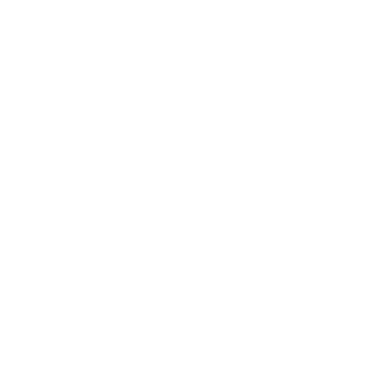

In [ ]:
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample, fig, ax)
# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

HTML(anim.to_html5_video())

You can save the animation (The trembling digit 😉) if you want

In [ ]:
# anim.save("my_first_spike.gif")

In [ ]:
print(f"The corresponding target is: {targets_it[0]}")

The corresponding target is: 2


Currently, we kept the spiking activity to be 100% whenever there is a 1 (i.e. white portion of the MNIST image). What if we reduce the spiking activity, make it sparse

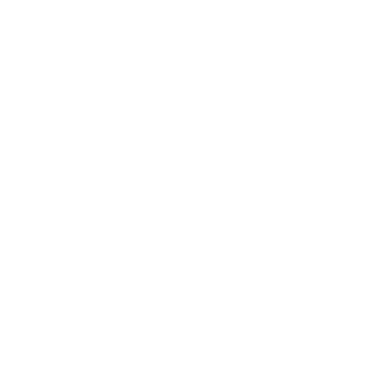

In [ ]:
spike_data = spikegen.rate(data_it, num_steps=num_steps, gain=0.25)

spike_data_sample2 = spike_data[:, 0, 0]
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample2, fig, ax)
HTML(anim.to_html5_video())

Lets compare how it varies for different spiking rates

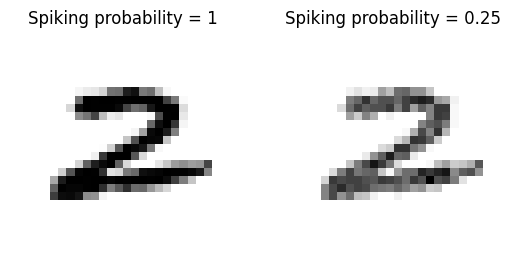

In [ ]:
plt.figure(facecolor="w")
plt.subplot(1,2,1)
plt.imshow(spike_data_sample.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Spiking probability = 1')

plt.subplot(1,2,2)
plt.imshow(spike_data_sample2.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Spiking probability = 0.25')

plt.show()

#### **Raster Plots**

We can also generate a raster plot of the input sample. We are not that used to raster plots, however when dealing with spikes, raster plots become necessary in understanding spiking behavior.

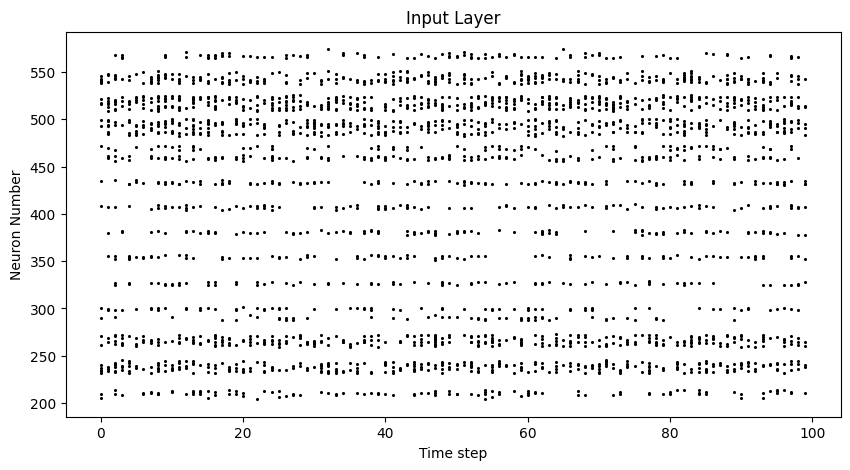

In [ ]:
# Reshape
spike_data_sample2 = spike_data_sample2.reshape((num_steps, -1))

# raster plot
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_data_sample2, ax, s=1.5, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

In the plot above,
+ The y-axis represents the neuron id from the inputs, since MNIST has 784 pixels, each pixel represents an input neuron.
+ Each input spikes according to the value of the pixel.
+ The x-axis represents the time window of spike train representation of the rate coded input.
+ Every dot represents whenever a spike occurs on a neuron during the time window. This shows us the overall spiking activity.

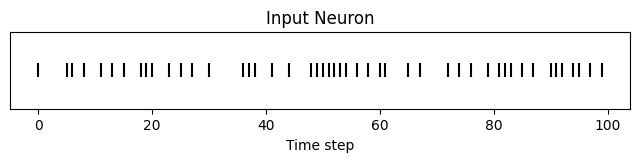

In [ ]:
idx = 500  # index into 100th neuron

fig = plt.figure(facecolor="w", figsize=(8, 1))
ax = fig.add_subplot(111)

splt.raster(spike_data_sample.reshape(num_steps, -1)[:, idx].unsqueeze(1), ax, s=100, c="black", marker="|")

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.show()

Try playing with the neuron `idx` above to see the different spiking activities

Now we understood the basics of rate coding. Lets move on to the next step. But before that, I have a few questions:

+ **Okay, so we dealt with spikes, is there any issue you see with spikes?**
+ **Will our activation functions operate well with spikes? Would they be meaningful? **


We have the input setup, now lets try to understand the neuron model in a spiking network.

## LIF neuron model

In this section, we will understand the leaky-integrate and fire neuron model.

In [ ]:
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

#### **Util functions for plotting**

The code block below has some util functions for plotting. Run the codeblock.

In [ ]:
#@title Plotting Utils
def plot_mem(mem, title=False):
  if title:
    plt.title(title)
  plt.plot(mem)
  plt.xlabel("Time step")
  plt.ylabel("Membrane Potential")
  plt.xlim([0, 50])
  plt.ylim([0, 1])
  plt.show()

def plot_step_current_response(cur_in, mem_rec, vline1):
  fig, ax = plt.subplots(2, figsize=(8,6),sharex=True)

  # Plot input current
  ax[0].plot(cur_in, c="tab:orange")
  ax[0].set_ylim([0, 0.2])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  ax[0].set_title("LIF Neuron Model With Step Input")

  # Plot membrane potential
  ax[1].plot(mem_rec)
  ax[1].set_ylim([0, 0.6])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")

  if vline1:
    ax[1].axvline(x=vline1, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.xlabel("Time step")

  plt.show()


def plot_current_pulse_response(cur_in, mem_rec, title, vline1=False, vline2=False, ylim_max1=False):

  fig, ax = plt.subplots(2, figsize=(8,6),sharex=True)

  # Plot input current
  ax[0].plot(cur_in, c="tab:orange")
  if not ylim_max1:
    ax[0].set_ylim([0, 0.2])
  else:
    ax[0].set_ylim([0, ylim_max1])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem_rec)
  ax[1].set_ylim([0, 1])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")

  if vline1:
    ax[1].axvline(x=vline1, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  if vline2:
    ax[1].axvline(x=vline2, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.xlabel("Time step")

  plt.show()

def compare_plots(cur1, cur2, cur3, mem1, mem2, mem3, vline1, vline2, vline3, vline4, title):
  # Generate Plots
  fig, ax = plt.subplots(2, figsize=(8,6),sharex=True)

  # Plot input current
  ax[0].plot(cur1)
  ax[0].plot(cur2)
  ax[0].plot(cur3)
  ax[0].set_ylim([0, 0.2])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem1)
  ax[1].plot(mem2)
  ax[1].plot(mem3)
  ax[1].set_ylim([0, 1])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")

  ax[1].axvline(x=vline1, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  ax[1].axvline(x=vline2, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  ax[1].axvline(x=vline3, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  ax[1].axvline(x=vline4, ymin=0, ymax=2.2, alpha = 0.25, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)

  plt.xlabel("Time step")

  plt.show()

def plot_cur_mem_spk(cur, mem, spk, thr_line=False, vline=False, title=False, ylim_max2=1.25):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,6), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input current
  ax[0].plot(cur, c="tab:orange")
  ax[0].set_ylim([0, 0.4])
  ax[0].set_xlim([0, 200])
  ax[0].set_ylabel("Input Current ($I_{in}$)")
  if title:
    ax[0].set_title(title)

  # Plot membrane potential
  ax[1].plot(mem)
  ax[1].set_ylim([0, ylim_max2])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
  if thr_line:
    ax[1].axhline(y=thr_line, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk, ax[2], s=400, c="black", marker="|")
  if vline:
    ax[2].axvline(x=vline, ymin=0, ymax=6.75, alpha = 0.15, linestyle="dashed", c="black", linewidth=2, zorder=0, clip_on=False)
  plt.ylabel("Output spikes")
  plt.yticks([])

  plt.show()

def plot_spk_mem_spk(spk_in, mem, spk_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,6), sharex=True,
                        gridspec_kw = {'height_ratios': [0.4, 1, 0.4]})

  # Plot input current
  splt.raster(spk_in, ax[0], s=400, c="black", marker="|")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title(title)
  plt.yticks([])

  # Plot membrane potential
  ax[1].plot(mem)
  ax[1].set_ylim([0, 1])
  ax[1].set_ylabel("Membrane Potential ($U_{mem}$)")
  ax[1].axhline(y=0.5, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  plt.xlabel("Time step")

  # Plot output spike using spikeplot
  splt.raster(spk_rec, ax[2], s=400, c="black", marker="|")
  plt.ylabel("Output spikes")
  plt.yticks([])

  plt.show()


def plot_reset_comparison(spk_in, mem_rec, spk_rec, mem_rec0, spk_rec0):
  # Generate Plots to Compare Reset Mechanisms
  fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10,6), sharex=True,
                        gridspec_kw = {'height_ratios': [0.4, 1, 0.4], 'wspace':0.05})

  # Reset by Subtraction: input spikes
  splt.raster(spk_in, ax[0][0], s=400, c="black", marker="|")
  ax[0][0].set_ylabel("Input Spikes")
  ax[0][0].set_title("Reset by Subtraction")
  ax[0][0].set_yticks([])

  # Reset by Subtraction: membrane potential
  ax[1][0].plot(mem_rec)
  ax[1][0].set_ylim([0, 0.7])
  ax[1][0].set_ylabel("Membrane Potential ($U_{mem}$)")
  ax[1][0].axhline(y=0.5, alpha=0.25, linestyle="dashed", c="black", linewidth=2)

  # Reset by Subtraction: output spikes
  splt.raster(spk_rec, ax[2][0], s=400, c="black", marker="|")
  ax[2][0].set_yticks([])
  ax[2][0].set_xlabel("Time step")
  ax[2][0].set_ylabel("Output Spikes")

  # Reset to Zero: input spikes
  splt.raster(spk_in, ax[0][1], s=400, c="black", marker="|")
  ax[0][1].set_title("Reset to Zero")
  ax[0][1].set_yticks([])

  # Reset to Zero: membrane potential
  ax[1][1].plot(mem_rec0)
  ax[1][1].set_ylim([0, 0.7])
  ax[1][1].axhline(y=0.5, alpha=0.25, linestyle="dashed", c="black", linewidth=2)
  ax[1][1].set_yticks([])
  ax[2][1].set_xlabel("Time step")

  # Reset to Zero: output spikes
  splt.raster(spk_rec0, ax[2][1], s=400, c="black", marker="|")
  ax[2][1].set_yticks([])

  plt.show()



def plot_snn_spikes(spk_in, spk1_rec, spk2_rec, title):
  # Generate Plots
  fig, ax = plt.subplots(3, figsize=(8,7), sharex=True,
                        gridspec_kw = {'height_ratios': [1, 1, 0.4]})

  # Plot input spikes
  splt.raster(spk_in[:,0], ax[0], s=0.03, c="black")
  ax[0].set_ylabel("Input Spikes")
  ax[0].set_title(title)

  # Plot hidden layer spikes
  splt.raster(spk1_rec.reshape(num_steps, -1), ax[1], s = 0.05, c="black")
  ax[1].set_ylabel("Hidden Layer")

  # Plot output spikes
  splt.raster(spk2_rec.reshape(num_steps, -1), ax[2], c="black", marker="|")
  ax[2].set_ylabel("Output Spikes")
  ax[2].set_ylim([0, 10])

  plt.show()

## The Spectrum of Neuron Models
A large variety of neuron models are out there, ranging from biophysically accurate models (i.e., the Hodgkin-Huxley models) to the extremely simple artificial neuron that pervades all facets of modern deep learning.

**Hodgkin-Huxley Neuron Models**$-$While biophysical models can reproduce electrophysiological results with a high degree of accuracy, their complexity makes them difficult to use at present.

**Artificial Neuron Model**$-$On the other end of the spectrum is the artificial neuron. The inputs are multiplied by their corresponding weights and passed through an activation function. This simplification has enabled deep learning researchers to perform incredible feats in computer vision, natural language processing, and many other machine learning-domain tasks.

**Leaky Integrate-and-Fire Neuron Models**$-$Somewhere in the middle of the divide lies the leaky integrate-and-fire (LIF) neuron model. It takes the sum of weighted inputs, much like the artificial neuron. But rather than passing it directly to an activation function, it will integrate the input over time with a leakage, much like an RC circuit. If the integrated value exceeds a threshold, then the LIF neuron will emit a voltage spike. The LIF neuron abstracts away the shape and profile of the output spike; it is simply treated as a discrete event. As a result, information is not stored within the spike, but rather the timing (or frequency) of spikes. Simple spiking neuron models have produced much insight into the neural code, memory, network dynamics, and more recently, deep learning. The LIF neuron sits in the sweet spot between biological plausibility and practicality.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_1_neuronmodels.png?raw=true' width="1000">
</center>

As shown above, spiking neurons fundamentally do the same operation of accumulation and produce an output activation accordingly. However, the key difference lies in the representation and transfer of information in the network. Instead of singular rate values, spiking neurons have an additional temporal effect, wherein they accumulate the spikes over time to derive an output activation accordingly.

The figure below shows how a simple spiking neuron operates.


<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_2_intuition.png?raw=true' width="500">
</center>

Given that these spikes are very short bursts of electrical activity, it is quite unlikely for all input spikes to arrive at the neuron body in precise unison. This indicates the presence of temporal dynamics that 'sustain' the input spikes, kind of like a delay.



---
**Optional: Derivation of LIF Neuron Model**

Now say some arbitrary time-varying current $I_{\rm in}(t)$ is injected into the neuron, be it via electrical stimulation or from other neurons. The total current in the circuit is conserved, so:

$$I_{\rm in}(t) = I_{R} + I_{C}$$

From Ohm's Law, the membrane potential measured between the inside and outside of the neuron $U_{\rm mem}$ is proportional to the current through the resistor:

$$I_{R}(t) = \frac{U_{\rm mem}(t)}{R}$$

The capacitance is a proportionality constant between the charge stored on the capacitor $Q$ and $U_{\rm mem}(t)$:


$$Q = CU_{\rm mem}(t)$$

The rate of change of charge gives the capacitive current:

$$\frac{dQ}{dt}=I_C(t) = C\frac{dU_{\rm mem}(t)}{dt}$$

Therefore:

$$I_{\rm in}(t) = \frac{U_{\rm mem}(t)}{R} + C\frac{dU_{\rm mem}(t)}{dt}$$

$$\implies RC \frac{dU_{\rm mem}(t)}{dt} = -U_{\rm mem}(t) + RI_{\rm in}(t)$$

The right hand side of the equation is of units **\[Voltage]**. On the left hand side of the equation, the term $\frac{dU_{\rm mem}(t)}{dt}$ is of units **\[Voltage/Time]**. To equate it to the left hand side (i.e., voltage), $RC$ must be of unit **\[Time]**. We refer to $\tau = RC$ as the time constant of the circuit:

$$ \tau \frac{dU_{\rm mem}(t)}{dt} = -U_{\rm mem}(t) + RI_{\rm in}(t)$$

The passive membrane is therefore described by a linear differential equation.

For a derivative of a function to be of the same form as the original function, i.e., $\frac{dU_{\rm mem}(t)}{dt} \propto U_{\rm mem}(t)$, this implies the solution is exponential with a time constant $\tau$.

Say the neuron starts at some value $U_{0}$ with no further input, i.e., $I_{\rm in}(t)=0$. The solution of the linear differential equation is:

$$U_{\rm mem}(t) = U_0e^{-\frac{t}{\tau}}$$

The general solution is shown below.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_4_RCmembrane.png?raw=true' width="500">
</center>

---

**Optional: Forward Euler Method to Solving the LIF Neuron Model**

We managed to find the analytical solution to the LIF neuron, but it is unclear how this might be useful in a neural network. This time, let's instead use the forward Euler method to solve the previous linear ordinary differential equation (ODE). This approach might seem arduous, but it gives us a discrete, recurrent representation of the LIF neuron. Once we reach this solution, it can be applied directly to a neural network. As before, the linear ODE describing the RC circuit is:

$$\tau \frac{dU(t)}{dt} = -U(t) + RI_{\rm in}(t)$$

The subscript from $U(t)$ is omitted for simplicity.

First, let's solve this derivative without taking the limit $\Delta t \rightarrow 0$:

$$\tau \frac{U(t+\Delta t)-U(t)}{\Delta t} = -U(t) + RI_{\rm in}(t)$$

For a small enough $\Delta t$, this gives a good enough approximation of continuous-time integration. Isolating the membrane at the following time step gives:

$$U(t+\Delta t) = U(t) + \frac{\Delta t}{\tau}\big(-U(t) + RI_{\rm in}(t)\big)$$

The following function represents this equation:

The default values are set to $R=50 M\Omega$ and $C=100pF$ (i.e., $\tau=5ms$).
These are quite realistic with respect to biological neurons.

In [ ]:
# Define the neuron model
def leaky_integrate_neuron(U, time_step=1e-3, I=0, R=5e7, C=1e-10):
  tau = R*C
  U = U + (time_step/tau)*(-U + I*R)
  return U



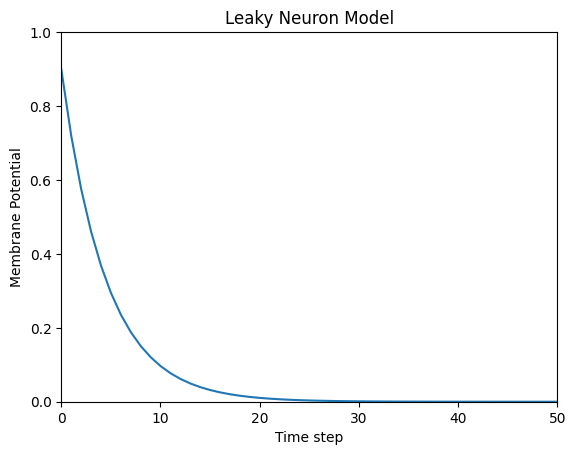

In [ ]:
num_steps = 100
U = 0.9
U_trace = []  # keeps a record of U for plotting

for step in range(num_steps):
  U_trace.append(U)
  U = leaky_integrate_neuron(U)  # solve next step of U

plot_mem(U_trace, "Leaky Neuron Model")

This similarity between nerve membranes and RC circuits was observed by [Louis Lapicque in 1907](https://core.ac.uk/download/pdf/21172797.pdf). He stimulated the nerve fiber of a frog with a brief electrical pulse, and found that neuron membranes could be approximated as a capacitor with a leakage. The snnTorch folks, name the LIF neuron after him as a homage. So do not get confused if the neuron is called `snn.Lapicque`


### Lapicque's neuron or LIF neuron model

Instantiate Lapicque's neuron using the following line of code. R & C are changed to simpler values, while keeping the previous time constant of $\tau=5\times10^{-3}$s.

In [ ]:
time_step = 1e-3
R = 5
C = 1e-3

# leaky integrate and fire neuron, tau=5e-3
lif1 = snn.Lapicque(R=R, C=C, time_step=time_step)

The neuron model is now stored in `lif1`. To use this neuron:

**Inputs**
* `cur_in`: each element of $I_{\rm in}$ is sequentially passed as an input (0 for now)
* `mem`: the membrane potential, previously $U[t]$, is also passed as input. Initialize it arbitrarily as $U[0] = 0.9~V$.

**Outputs**
* `spk_out`: output spike $S_{\rm out}[t+\Delta t]$ at the next time step ('1' if there is a spike; '0' if there is no spike)
* `mem`: membrane potential $U_{\rm mem}[t+\Delta t]$ at the next time step

These all need to be of type `torch.Tensor`.


In [ ]:
# Initialize membrane, input, and output
mem = torch.ones(1) * 0.9  # U=0.9 at t=0
cur_in = torch.zeros(num_steps, 1)  # I=0 for all t
spk_out = torch.zeros(1)  # initialize output spikes

These values are only for the initial time step $t=0$.
To analyze the evolution of `mem` over time, create a list `mem_rec` to record these values at every time step.

In [ ]:
# A list to store recordings of membrane potential
mem_rec = [mem]

Lets run a simple simulation now

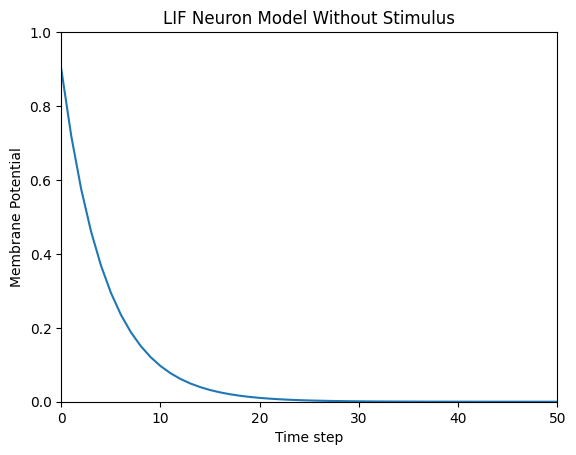

In [ ]:
# pass updated value of mem and cur_in[step]=0 at every time step
for step in range(num_steps):
  spk_out, mem = lif1(cur_in[step], mem)

  # Store recordings of membrane potential
  mem_rec.append(mem)

# crunch the list of tensors into one tensor
mem_rec = torch.stack(mem_rec)

plot_mem(mem_rec, "LIF Neuron Model Without Stimulus")

#### Now what if we give it inputs.


What type of behavior would it show?

In [ ]:
# Initialize input current pulse
cur_in = torch.cat((torch.zeros(10, 1), torch.ones(190, 1)*0.1), 0)  # input current turns on at t=10

# Initialize membrane, output and recordings
mem = torch.zeros(1)  # membrane potential of 0 at t=0
spk_out = torch.zeros(1)  # neuron needs somewhere to sequentially dump its output spikes
mem_rec = [mem]

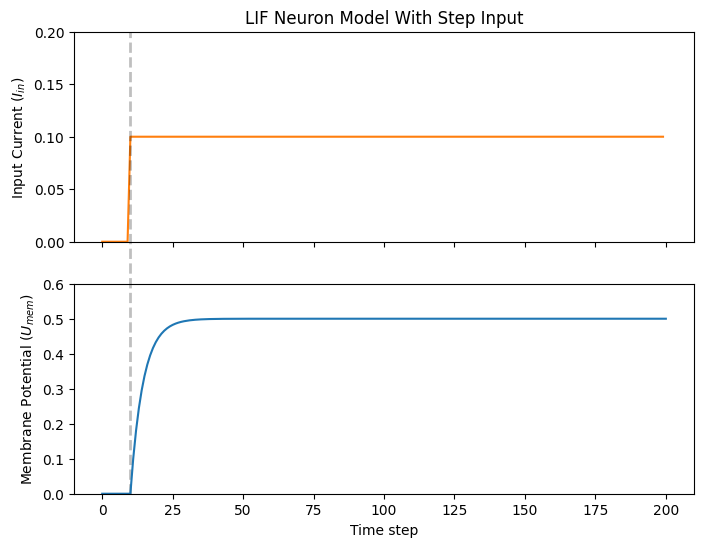

In [ ]:
num_steps = 200

# pass updated value of mem and cur_in[step] at every time step
for step in range(num_steps):
  spk_out, mem = lif1(cur_in[step], mem)
  mem_rec.append(mem)

# crunch -list- of tensors into one tensor
mem_rec = torch.stack(mem_rec)

plot_step_current_response(cur_in, mem_rec, 10)

What if we just send in a pulse input?

In [ ]:
# Initialize current pulse, membrane and outputs
cur_in1 = torch.cat((torch.zeros(10, 1), torch.ones(20, 1)*(0.1), torch.zeros(170, 1)), 0)  # input turns on at t=10, off at t=30
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec1 = [mem]

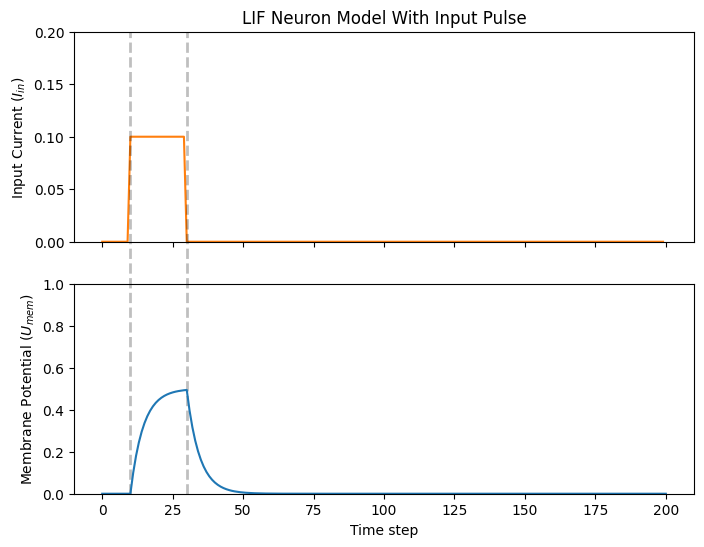

In [ ]:
# neuron simulation
for step in range(num_steps):
  spk_out, mem = lif1(cur_in1[step], mem)
  mem_rec1.append(mem)
mem_rec1 = torch.stack(mem_rec1)

plot_current_pulse_response(cur_in1, mem_rec1, "LIF Neuron Model With Input Pulse",
                            vline1=10, vline2=30)

$U_{\rm mem}$ rises just as it did for the step input, but now it decays with a time constant of $\tau$ as in our first simulation.

Let's deliver approximately the same amount of charge $Q = I \times t$ to the circuit in half the time. This means the input current amplitude must be increased by a little, and the time window must be decreased.

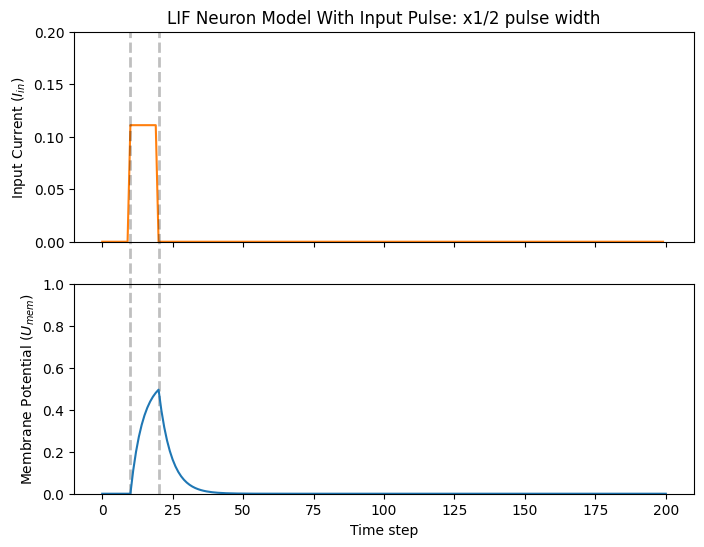

In [ ]:
# Increase amplitude of current pulse; half the time.
cur_in2 = torch.cat((torch.zeros(10, 1), torch.ones(10, 1)*0.111, torch.zeros(180, 1)), 0)  # input turns on at t=10, off at t=20
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec2 = [mem]

# neuron simulation
for step in range(num_steps):
  spk_out, mem = lif1(cur_in2[step], mem)
  mem_rec2.append(mem)
mem_rec2 = torch.stack(mem_rec2)

plot_current_pulse_response(cur_in2, mem_rec2, "LIF Neuron Model With Input Pulse: x1/2 pulse width",
                            vline1=10, vline2=20)

One more experiment, increase the amplitude of the pulse and reduce the time by quarter

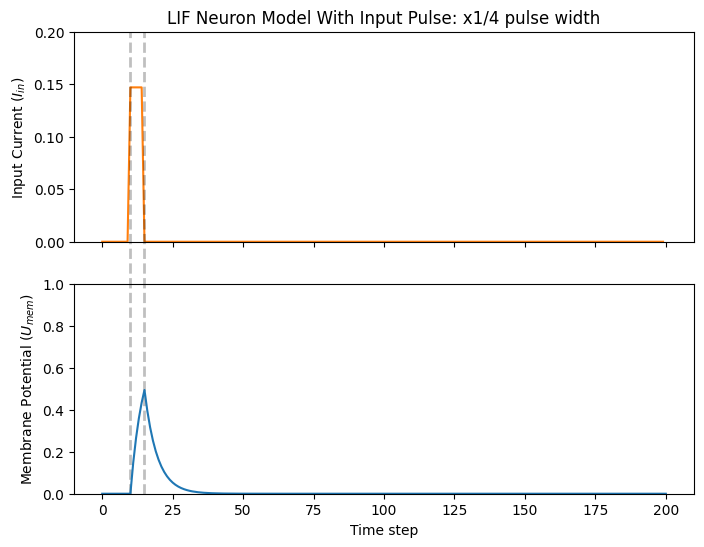

In [ ]:
# Increase amplitude of current pulse; quarter the time.
cur_in3 = torch.cat((torch.zeros(10, 1), torch.ones(5, 1)*0.147, torch.zeros(185, 1)), 0)  # input turns on at t=10, off at t=15
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec3 = [mem]

# neuron simulation
for step in range(num_steps):
  spk_out, mem = lif1(cur_in3[step], mem)
  mem_rec3.append(mem)
mem_rec3 = torch.stack(mem_rec3)

plot_current_pulse_response(cur_in3, mem_rec3, "LIF Neuron Model With Input Pulse: x1/4 pulse width",
                            vline1=10, vline2=15)

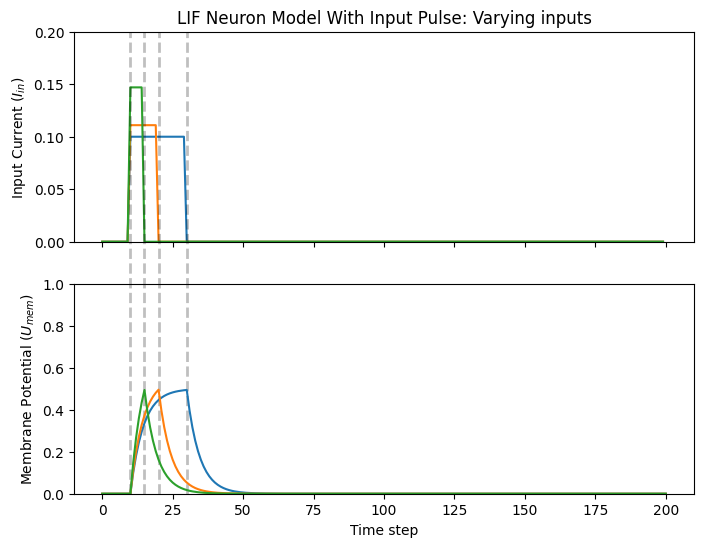

In [ ]:
compare_plots(cur_in1, cur_in2, cur_in3, mem_rec1, mem_rec2, mem_rec3, 10, 15,
              20, 30, "LIF Neuron Model With Input Pulse: Varying inputs")

So far, we have only seen how a neuron will react to spikes at the input. For a neuron to generate and emit its own spikes at the output, the passive membrane model must be combined with a threshold.

If the membrane potential exceeds this threshold, then a voltage spike will be generated, external to the passive membrane model.

The figure below shows how we apply a thresold to the leaky and integrate neuron. Everytime, the membrane potential reaches a threshold, the neuron emits an output spike.

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_4_spiking.png?raw=true' width="450">
</center>

Modify the `leaky_integrate_neuron` function from before to add a spike response.

In [ ]:
# R=5.1, C=5e-3 for illustrative purposes
def leaky_integrate_and_fire(mem, cur=0, threshold=1, time_step=1e-3, R=5.1, C=5e-3):
  tau_mem = R*C
  spk = (mem > threshold) # if membrane exceeds threshold, spk=1, else, 0
  mem = mem + (time_step/tau_mem)*(-mem + cur*R)
  return mem, spk

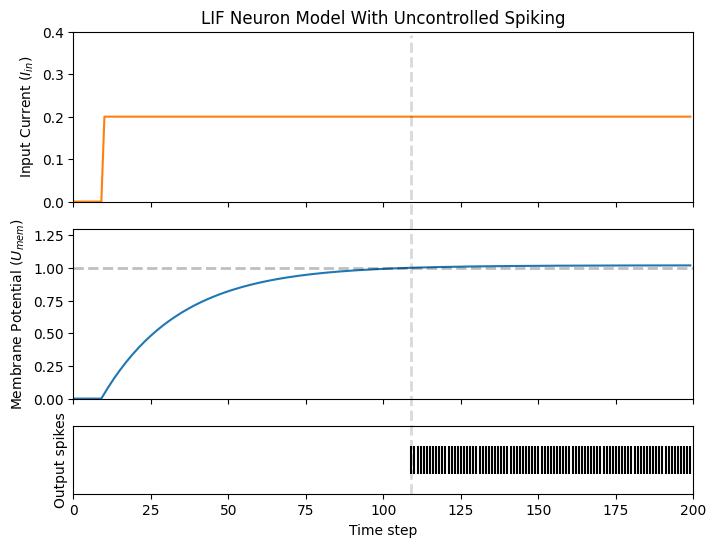

In [ ]:
# Small step current input
cur_in = torch.cat((torch.zeros(10), torch.ones(190)*0.2), 0)
mem = torch.zeros(1)
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk = leaky_integrate_and_fire(mem, cur_in[step])
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=1, vline=109, ylim_max2=1.3,
                 title="LIF Neuron Model With Uncontrolled Spiking")

**Any problem with the above plot?**




In [ ]:
# LIF w/Reset mechanism
def leaky_integrate_and_fire(mem, cur=0, threshold=1, time_step=1e-3, R=5.1, C=5e-3):
  tau_mem = R*C
  spk = (mem > threshold)
  mem = mem + (time_step/tau_mem)*(-mem + cur*R) - spk*threshold  # every time spk=1, subtract the threhsold
  return mem, spk

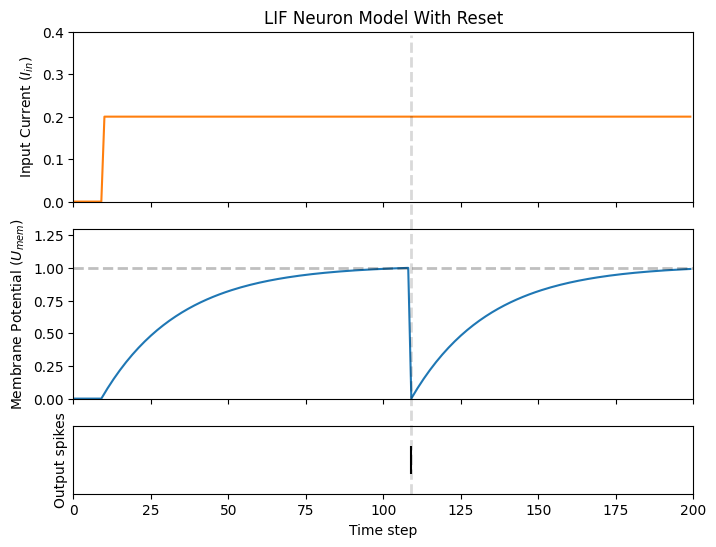

In [ ]:
# Small step current input
cur_in = torch.cat((torch.zeros(10), torch.ones(190)*0.2), 0)
mem = torch.zeros(1)
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  mem, spk = leaky_integrate_and_fire(mem, cur_in[step])
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=1, vline=109, ylim_max2=1.3,
                 title="LIF Neuron Model With Reset")

In [ ]:
# Create the same neuron as before using snnTorch
lif2 = snn.Lapicque(R=5.1, C=5e-3, time_step=1e-3)

print(f"Membrane potential time constant: {lif2.R * lif2.C:.3f}s")

Membrane potential time constant: 0.025s


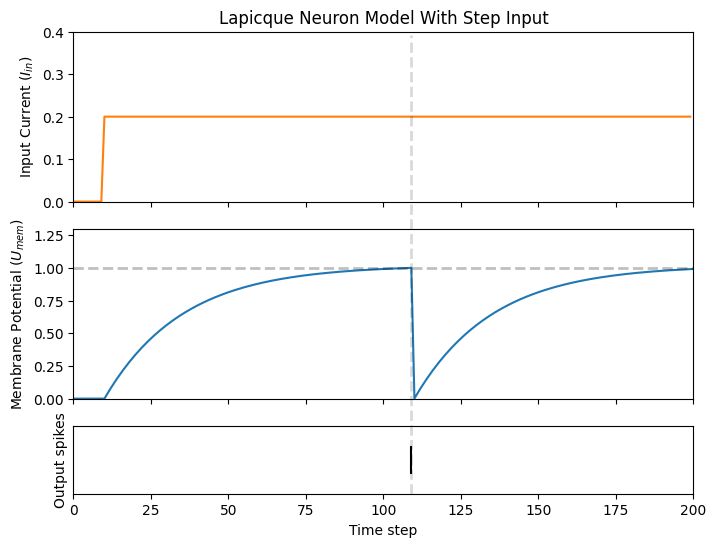

In [ ]:
# Initialize inputs and outputs
cur_in = torch.cat((torch.zeros(10, 1), torch.ones(190, 1)*0.2), 0)
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec = [mem]
spk_rec = [spk_out]

# Simulation run across 100 time steps.
for step in range(num_steps):
  spk_out, mem = lif2(cur_in[step], mem)
  mem_rec.append(mem)
  spk_rec.append(spk_out)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=1, vline=109, ylim_max2=1.3,
                 title="Lapicque Neuron Model With Step Input")

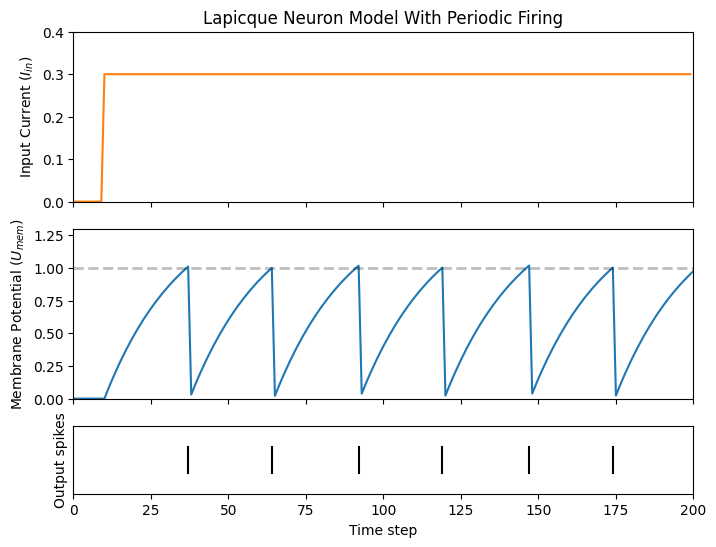

In [ ]:
# Initialize inputs and outputs
cur_in = torch.cat((torch.zeros(10, 1), torch.ones(190, 1)*0.3), 0)  # increased current
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec = [mem]
spk_rec = [spk_out]

# neuron simulation
for step in range(num_steps):
  spk_out, mem = lif2(cur_in[step], mem)
  mem_rec.append(mem)
  spk_rec.append(spk_out)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)


plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=1, ylim_max2=1.3,
                 title="Lapicque Neuron Model With Periodic Firing")

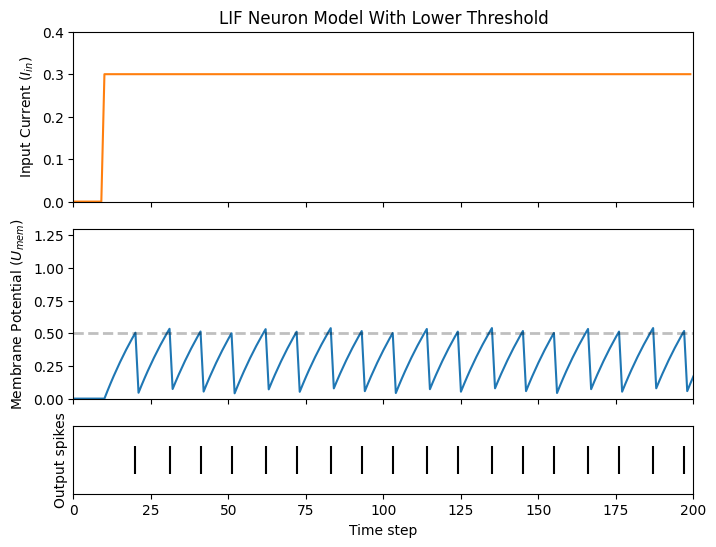

In [ ]:
# neuron with halved threshold
lif3 = snn.Lapicque(R=5.1, C=5e-3, time_step=1e-3, threshold=0.5)

# Initialize inputs and outputs
cur_in = torch.cat((torch.zeros(10, 1), torch.ones(190, 1)*0.3), 0)
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec = [mem]
spk_rec = [spk_out]

# Neuron simulation
for step in range(num_steps):
  spk_out, mem = lif3(cur_in[step], mem)
  mem_rec.append(mem)
  spk_rec.append(spk_out)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=0.5, ylim_max2=1.3,
                 title="LIF Neuron Model With Lower Threshold")

In [ ]:
# Create a 1-D random spike train. Each element has a probability of 40% of firing.
spk_in = spikegen.rate_conv(torch.ones((num_steps,1)) * 0.40)

There are 80 total spikes out of 200 time steps.


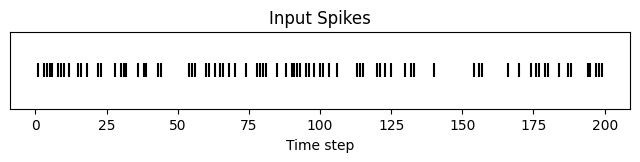

In [ ]:
print(f"There are {int(sum(spk_in))} total spikes out of {len(spk_in)} time steps.")

fig = plt.figure(facecolor="w", figsize=(8, 1))
ax = fig.add_subplot(111)

splt.raster(spk_in.reshape(num_steps, -1), ax, s=100, c="black", marker="|")
plt.title("Input Spikes")
plt.xlabel("Time step")
plt.yticks([])
plt.show()

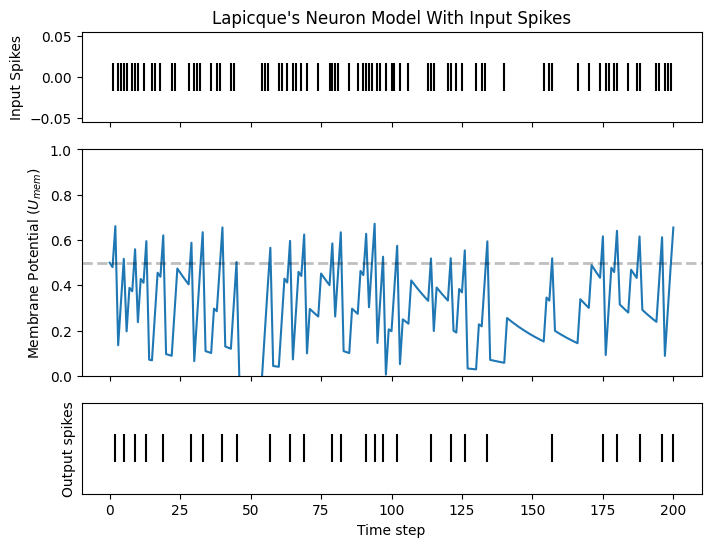

In [ ]:
# Initialize inputs and outputs
mem = torch.ones(1)*0.5
spk_out = torch.zeros(1)
mem_rec = [mem]
spk_rec = [spk_out]

# Neuron simulation
for step in range(num_steps):
  spk_out, mem = lif3(spk_in[step], mem)
  spk_rec.append(spk_out)
  mem_rec.append(mem)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_spk_mem_spk(spk_in, mem_rec, spk_rec, "Lapicque's Neuron Model With Input Spikes")

**Now what if we reset the potential to 0 instead of subtracting by the threshold**

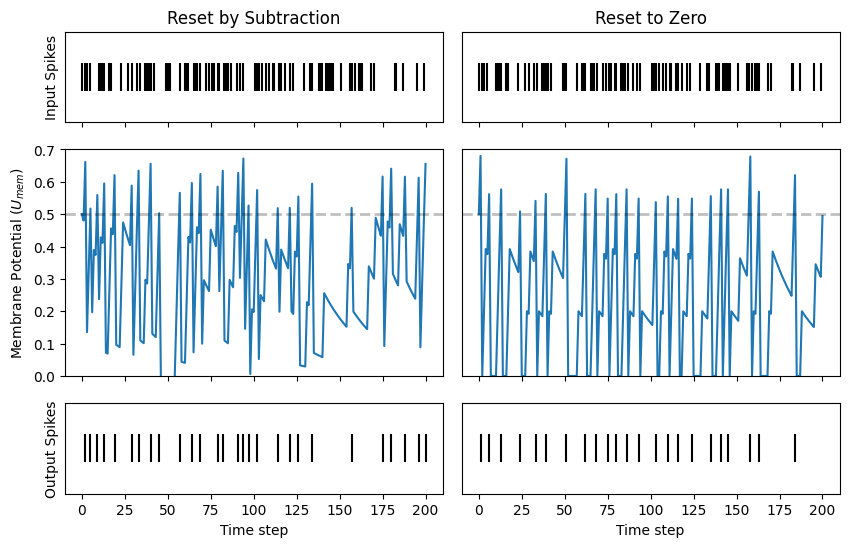

In [ ]:
# Neuron with reset_mechanism set to "zero"
lif4 = snn.Lapicque(R=5.1, C=5e-3, time_step=1e-3, threshold=0.5, reset_mechanism="zero")

# Initialize inputs and outputs
spk_in = spikegen.rate_conv(torch.ones((num_steps, 1)) * 0.40)
mem = torch.ones(1)*0.5
spk_out = torch.zeros(1)
mem_rec0 = [mem]
spk_rec0 = [spk_out]

# Neuron simulation
for step in range(num_steps):
  spk_out, mem = lif4(spk_in[step], mem)
  spk_rec0.append(spk_out)
  mem_rec0.append(mem)

# convert lists to tensors
mem_rec0 = torch.stack(mem_rec0)
spk_rec0 = torch.stack(spk_rec0)

plot_reset_comparison(spk_in, mem_rec, spk_rec, mem_rec0, spk_rec0)


So which one is better? Applying `"subtract"` (the default value in `reset_mechanism`) is less lossy, because it does not ignore how much the membrane exceeds the threshold by.

On the other hand, applying a hard reset with `"zero"` promotes sparsity and potentially less power consumption when running on dedicated neuromorphic hardware. Both options are available for you to experiment with.


Now, we are done with the LIF neuron completely. So lets move on the next part. We laid the foundation for finally building a neural network.
Yayy.


## Feedforward Spiking neural network

We learnt about the encoding mechanisms and the LIF neuron model till now. I know it was a lot, but it will be worth it. Trust me.

<img src="https://media2.giphy.com/media/v1.Y2lkPTc5MGI3NjExZnN4aXZydmg0eHlsdHY4NTA0NzY2c2xwb3NmY2UzeHdyaGgycTBmNCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/yQh6DfCCoYcQZc3huF/giphy.gif" >

So, we will start with instantiating a simpler neuron model, since including $R$, $C$, $\Delta t$, $U_{\rm thr}$, and the choice of reset mechanism is too cumbersome for us to define in a neural network.

We will start by defining a simpler LIF.

We will condense the RC values into a singular beta variable

In [ ]:
def leaky_integrate_and_fire(mem, x, w, beta, threshold=1):
  spk = (mem > threshold) # if membrane exceeds threshold, spk=1, else, 0
  mem = beta * mem + w*x - spk*threshold
  return spk, mem

In [ ]:
# set neuronal parameters
delta_t = torch.tensor(1e-3)
tau = torch.tensor(5e-3)
beta = torch.exp(-delta_t/tau)

print(f"The decay rate is: {beta:.3f}")

The decay rate is: 0.819


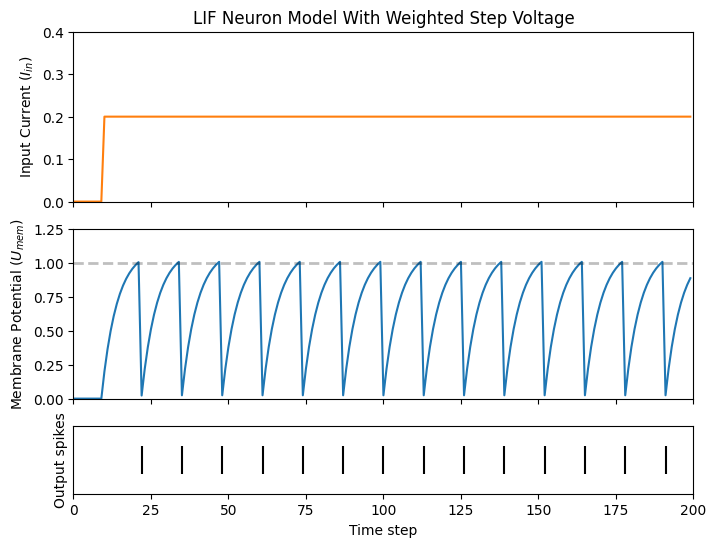

In [ ]:
num_steps = 200

# initialize inputs/outputs + small step current input
x = torch.cat((torch.zeros(10), torch.ones(190)*0.5), 0)
mem = torch.zeros(1)
spk_out = torch.zeros(1)
mem_rec = []
spk_rec = []

# neuron parameters
w = 0.4
beta = 0.819

# neuron simulation
for step in range(num_steps):
  spk, mem = leaky_integrate_and_fire(mem, x[step], w=w, beta=beta)
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(x*w, mem_rec, spk_rec, thr_line=1,
                 title="LIF Neuron Model With Weighted Step Voltage")

An even simpler neuron is defined by `snn.Leaky()` in the snnTorch.

In [ ]:
lif1 = snn.Leaky(beta=0.8)

The neuron model is now stored in `lif1`. To use this neuron:

**Inputs**
* `cur_in`: each element of $W\times X[t]$ is sequentially passed as an input
* `mem`: the previous step membrane potential, $U[t-1]$, is also passed as input.

**Outputs**
* `spk_out`: output spike $S[t]$ ('1' if there is a spike; '0' if there is no spike)
* `mem`: membrane potential $U[t]$ of the present step

These all need to be of type `torch.Tensor`. Note that here, we assume the input current has already been weighted before passing into the `snn.Leaky` neuron. This will make more sense when we construct a network-scale model.

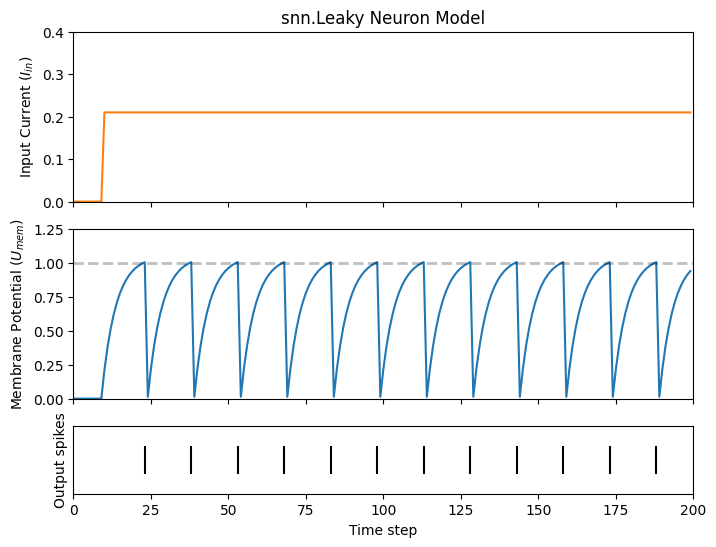

In [ ]:
# Small step current input
w=0.21
cur_in = torch.cat((torch.zeros(10), torch.ones(190)*w), 0)
mem = torch.zeros(1)
spk = torch.zeros(1)
mem_rec = []
spk_rec = []

# neuron simulation
for step in range(num_steps):
  spk, mem = lif1(cur_in[step], mem)
  mem_rec.append(mem)
  spk_rec.append(spk)

# convert lists to tensors
mem_rec = torch.stack(mem_rec)
spk_rec = torch.stack(spk_rec)

plot_cur_mem_spk(cur_in, mem_rec, spk_rec, thr_line=1,
                 title="snn.Leaky Neuron Model")

So far, we have only considered how a single neuron responds to input stimulus. snnTorch makes it straightforward to scale this up to a deep neural network. In this section, we will create a 3-layer fully-connected neural network of dimensions 784-1000-10. Compared to our simulations so far, each neuron will now integrate over many more incoming input spikes.


<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial2/2_8_fcn.png?raw=true' width="600">
</center>

PyTorch is used to form the connections between neurons, and snnTorch to create the neurons. First, initialize all layers.

In [ ]:
# layer parameters
num_inputs = 784
num_hidden = 1000
num_outputs = 10
beta = 0.99

# initialize layers
fc1 = nn.Linear(num_inputs, num_hidden)
lif1 = snn.Leaky(beta=beta)
fc2 = nn.Linear(num_hidden, num_outputs)
lif2 = snn.Leaky(beta=beta)

Next, initialize the hidden variables and outputs of each spiking neuron.
As networks increase in size, this becomes more tedious. The static method `init_leaky()` can be used to take care of this. All neurons in snnTorch have their own initialization methods that follow this same syntax, e.g., `init_lapicque()`. The shape of the hidden states are automatically initialized based on the input data dimensions during the first forward pass.

In [ ]:
# Initialize hidden states
mem1 = lif1.init_leaky()
mem2 = lif2.init_leaky()

# record outputs
mem2_rec = []
spk1_rec = []
spk2_rec = []

Create an input spike train to pass to the network. There are 200 time steps to simulate across 784 input neurons, i.e., the input originally has dimensions of $200 \times 784$. However, neural nets typically process data in minibatches. snnTorch uses time-first dimensionality:

[$time \times batch\_size \times feature\_dimensions$]

So 'unsqueeze' the input along `dim=1` to indicate 'one batch' of data. The dimensions of this input tensor must be 200 $\times$ 1 $\times$ 784:

In [ ]:
spk_in = spikegen.rate_conv(torch.rand((200, 784))).unsqueeze(1)
print(f"Dimensions of spk_in: {spk_in.size()}")

Dimensions of spk_in: torch.Size([200, 1, 784])


Now it's finally time to run a full simulation.
An intuitive way to think about how PyTorch and snnTorch work together is that PyTorch routes the neurons together, and snnTorch loads the results into spiking neuron models. In terms of coding up a network, these spiking neurons can be treated like time-varying activation functions.

Here is a sequential account of what's going on:

*  The $i^{th}$ input from `spk_in` to the $j^{th}$ neuron is weighted by the parameters initialized in `nn.Linear`: $X_{i} \times W_{ij}$
* This generates the input current term, contributing to $U[t+1]$ of the spiking neuron
* If $U[t+1] > U_{\rm thr}$, then a spike is triggered from this neuron
* This spike is weighted by the second layer weight, and the above process is repeated for all inputs, weights, and neurons.
* If there is no spike, then nothing is passed to the post-synaptic neuron.

The only difference from our simulations thus far is that we are now scaling the input current with a weight generated by `nn.Linear`, rather than manually setting $W$ ourselves.

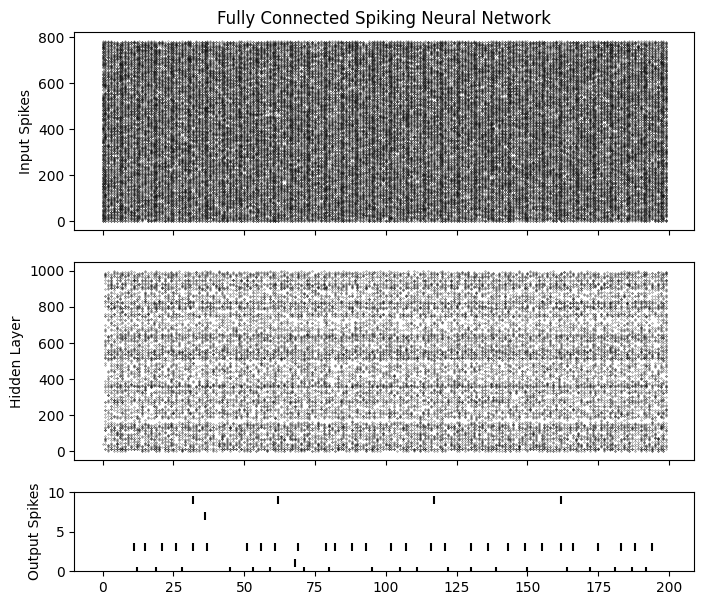

In [ ]:
# network simulation
for step in range(num_steps):
    cur1 = fc1(spk_in[step]) # post-synaptic current <-- spk_in x weight
    spk1, mem1 = lif1(cur1, mem1) # mem[t+1] <--post-syn current + decayed membrane
    cur2 = fc2(spk1)
    spk2, mem2 = lif2(cur2, mem2)

    mem2_rec.append(mem2)
    spk1_rec.append(spk1)
    spk2_rec.append(spk2)

# convert lists to tensors
mem2_rec = torch.stack(mem2_rec)
spk1_rec = torch.stack(spk1_rec)
spk2_rec = torch.stack(spk2_rec)

plot_snn_spikes(spk_in, spk1_rec, spk2_rec, "Fully Connected Spiking Neural Network")


At this stage, the spikes don't have any real meaning. The inputs and weights are all randomly initialized, and no training has taken place. But the spikes  should appear to be propagating from the first layer through to the output. If you are not seeing any spikes, then you might have been unlucky in the weight initialization lottery - you might want to try re-running the last four code-blocks.

`spikeplot.spike_count` can create a spike counter of the output layer. The following animation will take some time to generate. <br>



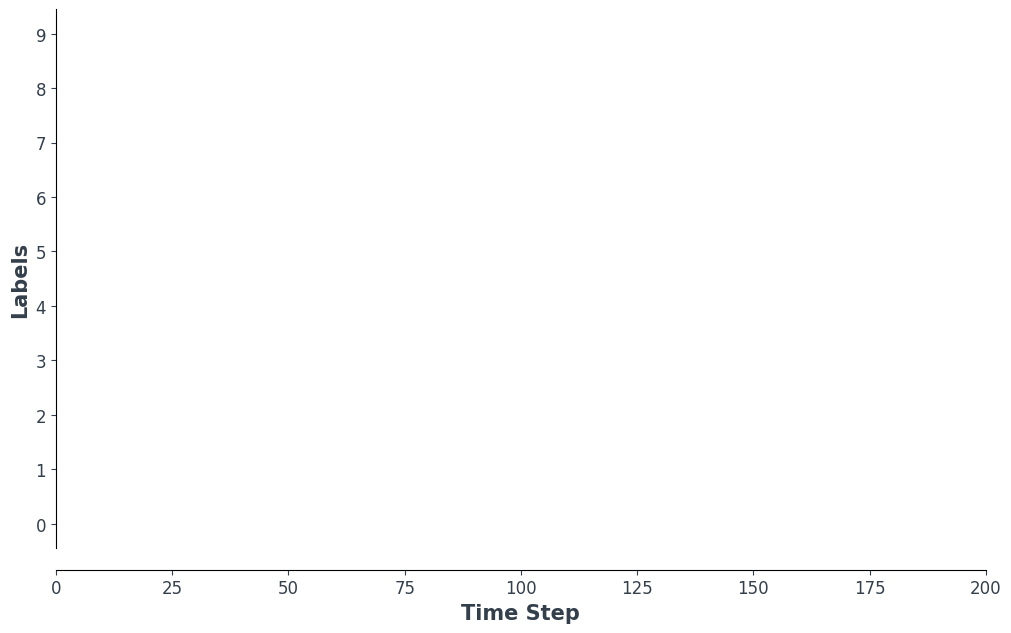

In [ ]:
from IPython.display import HTML

fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))
labels=['0', '1', '2', '3', '4', '5', '6', '7', '8','9']
spk2_rec = spk2_rec.squeeze(1).detach().cpu()

# plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

#  Plot spike count histogram
anim = splt.spike_count(spk2_rec, fig, ax, labels=labels, animate=True)
HTML(anim.to_html5_video())
# anim.save("spike_bar.mp4")

`spikeplot.traces` lets you visualize the membrane potential traces. We will plot 9 out of 10 output neurons.


Compare it to the animation and raster plot above to see if you can match the traces to the neuron.

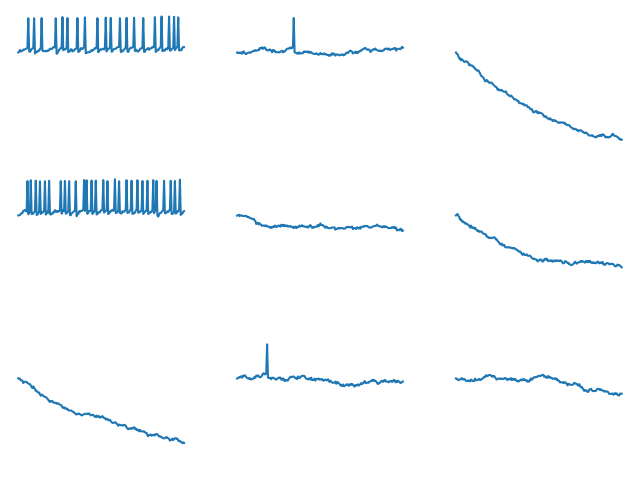

In [ ]:
# plot membrane potential traces
splt.traces(mem2_rec.squeeze(1), spk=spk2_rec.squeeze(1))
fig = plt.gcf()
fig.set_size_inches(8, 6)

## Training the spiking network

We all should have noticed that the output response has no meaning at all with respect to the input. Therefore we need to train the network to do something.

Finally, we reach the part where we get the network to do something meaningful.

In this context, we will train the spiking network on MNIST dataset to classify the digits.



##### We will start with setting up the static MNIST dataset.

In [ ]:
# dataloader arguments
batch_size = 128
data_path='/tmp/data/mnist'

dtype = torch.float
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [ ]:
# Define a transform
transform = transforms.Compose([
            transforms.Resize((28, 28)),
            transforms.Grayscale(),
            transforms.ToTensor(),
            transforms.Normalize((0,), (1,))])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(data_path, train=False, download=True, transform=transform)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=True)

### Define  the network

In [ ]:
# Network Architecture
num_inputs = 28*28
num_hidden = 1000
num_outputs = 10

# Temporal Dynamics
num_steps = 25
beta = 0.95

In [ ]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        self.fc1 = nn.Linear(num_inputs, num_hidden)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(num_hidden, num_outputs)
        self.lif2 = snn.Leaky(beta=beta)

    def forward(self, x):

        # Initialize hidden states at t=0
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        # Record the final layer
        spk2_rec = []
        mem2_rec = []

        for step in range(num_steps):
            cur1 = self.fc1(x)
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)

        return torch.stack(spk2_rec, dim=0), torch.stack(mem2_rec, dim=0)

# Load the network onto CUDA if available
net = Net().to(device)

The code in the `forward()` function will only be called once the input argument `x` is explicitly passed into `net`.

* `fc1` applies a linear transformation to all input pixels from the MNIST dataset;
* `lif1` integrates the weighted input over time, emitting a spike if the threshold condition is met;
* `fc2` applies a linear transformation to the output spikes of `lif1`;
* `lif2` is another spiking neuron layer, integrating the weighted spikes over time.

### Utils functions

Some more utils functions

In [ ]:
# pass data into the network, sum the spikes over time
# and compare the neuron with the highest number of spikes
# with the target

def print_batch_accuracy(data, targets, train=False):
    output, _ = net(data.view(batch_size, -1))
    _, idx = output.sum(dim=0).max(1)
    acc = np.mean((targets == idx).detach().cpu().numpy())

    if train:
        print(f"Train set accuracy for a single minibatch: {acc*100:.2f}%")
    else:
        print(f"Test set accuracy for a single minibatch: {acc*100:.2f}%")

def train_printer(
    data, targets, epoch,
    counter, iter_counter,
        loss_hist, test_loss_hist, test_data, test_targets):
    print(f"Epoch {epoch}, Iteration {iter_counter}")
    print(f"Train Set Loss: {loss_hist[counter]:.2f}")
    print(f"Test Set Loss: {test_loss_hist[counter]:.2f}")
    print_batch_accuracy(data, targets, train=True)
    print_batch_accuracy(test_data, test_targets, train=False)
    print("\n")

**Define the loss function**

In [ ]:
loss = nn.CrossEntropyLoss()

**Define the optimizer**

In [ ]:
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4, betas=(0.9, 0.999))

**Move the data to the device**

In [ ]:
data, targets = next(iter(train_loader))
data = data.to(device)
targets = targets.to(device)

In [ ]:
spk_rec, mem_rec = net(data.view(batch_size, -1))
print(mem_rec.size())

torch.Size([25, 128, 10])


The recording of the membrane potential is taken across:
* 25 time steps
* 128 samples of data
* 10 output neurons

We wish to calculate the loss at every time step, and sum these up together, as per Equation $(10)$:

**Evaluate the loss before training and check its performance**

In [ ]:
# initialize the total loss value
loss_val = torch.zeros((1), dtype=dtype, device=device)

# sum loss at every step
for step in range(num_steps):
  loss_val += loss(mem_rec[step], targets)

print(f"Training loss: {loss_val.item():.3f}")

Training loss: 61.486


In [ ]:
print_batch_accuracy(data, targets, train=True)

Train set accuracy for a single minibatch: 3.12%


**What do you think about the accuracy?**

What if we train once over the single batch?

In [ ]:
# clear previously stored gradients
optimizer.zero_grad()

# calculate the gradients
loss_val.backward()

# weight update
optimizer.step()

In [ ]:
# calculate new network outputs using the same data
spk_rec, mem_rec = net(data.view(batch_size, -1))

# initialize the total loss value
loss_val = torch.zeros((1), dtype=dtype, device=device)

# sum loss at every step
for step in range(num_steps):
  loss_val += loss(mem_rec[step], targets)

print(f"Training loss: {loss_val.item():.3f}")
print_batch_accuracy(data, targets, train=True)

Training loss: 50.798
Train set accuracy for a single minibatch: 42.97%


Interesting results right!!!
The loss decreased and the accuracy increased significantly. Now lets train the network on the entire training set.

This may take some time to run but in the meanwhile if you have any questions, feel free to ask.

In [ ]:
num_epochs = 1
loss_hist = []
test_loss_hist = []
counter = 0

# Outer training loop
for epoch in range(num_epochs):
    iter_counter = 0
    train_batch = iter(train_loader)

    # Minibatch training loop
    for data, targets in train_batch:
        data = data.to(device)
        targets = targets.to(device)

        # forward pass
        net.train()
        spk_rec, mem_rec = net(data.view(batch_size, -1))

        # initialize the loss & sum over time
        loss_val = torch.zeros((1), dtype=dtype, device=device)
        for step in range(num_steps):
            loss_val += loss(mem_rec[step], targets)

        # Gradient calculation + weight update
        optimizer.zero_grad()
        loss_val.backward()
        optimizer.step()

        # Store loss history for future plotting
        loss_hist.append(loss_val.item())

        # Test set
        with torch.no_grad():
            net.eval()
            test_data, test_targets = next(iter(test_loader))
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            # Test set forward pass
            test_spk, test_mem = net(test_data.view(batch_size, -1))

            # Test set loss
            test_loss = torch.zeros((1), dtype=dtype, device=device)
            for step in range(num_steps):
                test_loss += loss(test_mem[step], test_targets)
            test_loss_hist.append(test_loss.item())

            # Print train/test loss/accuracy
            if counter % 50 == 0:
                train_printer(
                    data, targets, epoch,
                    counter, iter_counter,
                    loss_hist, test_loss_hist,
                    test_data, test_targets)
            counter += 1
            iter_counter +=1

Epoch 0, Iteration 0
Train Set Loss: 54.66
Test Set Loss: 48.70
Train set accuracy for a single minibatch: 58.59%
Test set accuracy for a single minibatch: 63.28%


Epoch 0, Iteration 50
Train Set Loss: 15.06
Test Set Loss: 8.51
Train set accuracy for a single minibatch: 89.84%
Test set accuracy for a single minibatch: 89.84%


Epoch 0, Iteration 100
Train Set Loss: 11.29
Test Set Loss: 12.03
Train set accuracy for a single minibatch: 85.94%
Test set accuracy for a single minibatch: 87.50%


Epoch 0, Iteration 150
Train Set Loss: 8.23
Test Set Loss: 9.30
Train set accuracy for a single minibatch: 89.06%
Test set accuracy for a single minibatch: 92.97%


Epoch 0, Iteration 200
Train Set Loss: 8.19
Test Set Loss: 10.85
Train set accuracy for a single minibatch: 89.06%
Test set accuracy for a single minibatch: 86.72%


Epoch 0, Iteration 250
Train Set Loss: 9.08
Test Set Loss: 11.84
Train set accuracy for a single minibatch: 92.19%
Test set accuracy for a single minibatch: 84.38%


Epoch 

### Plot the training loss and the test loss

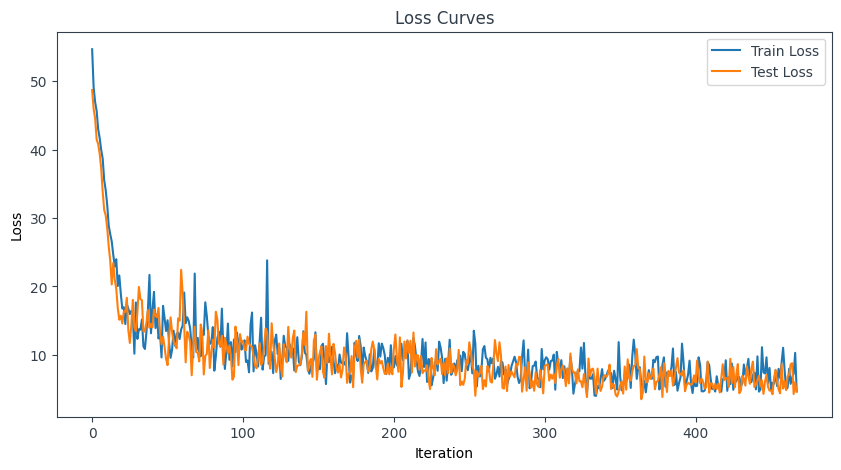

In [ ]:
# Plot Loss
fig = plt.figure(facecolor="w", figsize=(10, 5))
plt.plot(loss_hist)
plt.plot(test_loss_hist)
plt.title("Loss Curves")
plt.legend(["Train Loss", "Test Loss"])
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.show()

### Lets evaluate on the test set

In [ ]:
total = 0
correct = 0

# drop_last switched to False to keep all samples
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True, drop_last=False)

with torch.no_grad():
  net.eval()
  for data, targets in test_loader:
    data = data.to(device)
    targets = targets.to(device)

    # forward pass
    test_spk, _ = net(data.view(data.size(0), -1))

    # calculate total accuracy
    _, predicted = test_spk.sum(dim=0).max(1)
    total += targets.size(0)
    correct += (predicted == targets).sum().item()

print(f"Total correctly classified test set images: {correct}/{total}")
print(f"Test Set Accuracy: {100 * correct / total:.2f}%")

Total correctly classified test set images: 9467/10000
Test Set Accuracy: 94.67%


Yayy! we trained our spiking neural network. Feel free to tweak the network parameters, hyperparameters, decay rate, using a learning rate scheduler etc. to see if you can improve the network performance.

As for learning rules, we used a version of backprop, however, it is not the most efficient rule for spiking networks. Researchers have explored a variety of approaches which can be used to train the networks. However, we can see that training spiking networks is becoming easier and writing code for it is similar to the rate based coutnerparts.

### Bonus

Do you know, there are a lot more ways of training spiking networks which do not need backpropagation. Those rules are more efficient while performing similar to backprop.

Here are some resources that you can use to know more about spiking neural networks.
+ [Spiking neuron models: Single neurons, populations, plasticity](https://books.google.com/books?hl=en&lr=&id=Rs4oc7HfxIUC&oi=fnd&pg=PR11&dq=spiking+neural+networks+review+gerstner&ots=2Tb5CSaIYa&sig=0W0rdA3jwao-53YuH2ShbARlMJM#v=onepage&q=spiking%20neural%20networks%20review%20gerstner&f=false) A book on the basics of neuron models, understanding plasticity and bio physics of neurons.

+ [Hebbian learning and spiking neurons](https://journals.aps.org/pre/abstract/10.1103/PhysRevE.59.4498), details on the basic learning mechanisms with spiking neurons.

+ [Networks of spiking neurons: the third generation of neural network models](https://www.sciencedirect.com/science/article/pii/S0893608097000117) , a more comprehensive review on SNNs

+ [Unsupervised learning of digit recognition using spike-timing-dependent plasticity](https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2015.00099/full), the most popular unsupervised learning rule with SNNs, known as spike timing dependent plasticity (STDP).

+ [Deep learning in spiking neural networks](https://www.sciencedirect.com/science/article/pii/S0893608018303332), review of deep spiking networks with different deep learning based strategies.

+ [Spiking neural networks and online learning: An overview and perspectives](https://www.sciencedirect.com/science/article/pii/S0893608019302655), a perspective on SNNs and their online learning capabilities.

+ [Surrogate gradient learning in spiking neural networks: Bringing the power of gradient-based optimization to spiking neural networks](https://ieeexplore.ieee.org/abstract/document/8891809/), bio-plausible alternatives to backpropagation, which address the weight transport problem.


#### Thanks a lot for joining this tutorial. I hope that everyone was able to learn something from this and if you have any cool ideas that we could collaborate on, feel free to reach out. Thank you
<img src="https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExenN4cWduZ3Nkc2t1MTQ1M3lyZzRhamQzdnBzcmVvMXJoN2loNzczNCZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/6C4y1oxC6182MsyjvK/giphy.gif">

### More bonus

#### The LIF model and the output spike generation
$$U[t+1] = \underbrace{\beta U[t]}_\text{decay} + \underbrace{WX[t+1]}_\text{input} - \underbrace{R[t]}_\text{reset} \tag{1}$$

where the input synaptic current is interpreted as $I_{\rm in}[t] = WX[t]$, and $X[t]$ may be some arbitrary input of spikes, a step/time-varying voltage, or unweighted step/time-varying current. Spiking is represented with the following equation, where if the membrane potential exceeds the threshold, a spike is emitted:

$$S[t] = \begin{cases} 1, &\text{if}~U[t] > U_{\rm thr} \\
0, &\text{otherwise}\end{cases} \tag{2}$$


#### The Non-Differentiability of Spikes
##### **Training Using the Backprop Algorithm**

An alternative way to represent the relationship between $S$ and $U$ in $(2)$ is:

$$S[t] = \Theta(U[t] - U_{\rm thr}) \tag{3}$$

where $\Theta(\cdot)$ is the Heaviside step function:

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial3/3_2_spike_descrip.png?raw=true' width="600">
</center>

Training a network in this form poses some serious challenges. Consider a single, isolated time step of the computational graph as shown in the *forward pass* below:

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial5/non-diff.png?raw=true' width="400">
</center>

The goal is to train the network using the gradient of the loss with respect to the weights, such that the weights are updated to minimize the loss. The backpropagation algorithm achieves this using the chain rule:

$$\frac{\partial \mathcal{L}}{\partial W} =
\frac{\partial \mathcal{L}}{\partial S}
\underbrace{\frac{\partial S}{\partial U}}_{\{0, \infty\}}
\frac{\partial U}{\partial I}\
\frac{\partial I}{\partial W}\ \tag{4}$$

From $(1)$, $\partial I/\partial W=X$, and $\partial U/\partial I=1$. While we have not yet defined a loss function, we can assume $\partial \mathcal{L}/\partial S$ has an analytical solution, in a similar form to the cross-entropy or mean-square error loss (more on that shortly).

However, the term that we are going to grapple with is $\partial S/\partial U$. The derivative of the Heaviside step function from $(3)$ is the Dirac Delta function, which evaluates to 0 everywhere, except at the threshold $U_{\rm thr} = \theta$, where it tends to infinity. This means the gradient will almost always be nulled to zero (or saturated if $U$ sits precisely at the threshold), and no learning can take place. This is known as the **dead neuron problem**.


The most common way to address the dead neuron problem is to keep the Heaviside function as it is during the forward pass, but swap the derivative term $\partial S/\partial U$ for something that does not kill the learning process during the backward pass, which will be denoted $\partial \tilde{S}/\partial U$. This might sound odd, but it turns out that neural networks are quite robust to such approximations. This is commonly known as the *surrogate gradient* approach.

The default method in snnTorch (as of v0.6.0) is to smooth the Heaviside function with the arctangent function. The backward-pass derivative used is:

$$ \frac{\partial \tilde{S}}{\partial U} \leftarrow \frac{1}{\pi}\frac{1}{(1+[U\pi]^2)} \tag{5}$$

where the left arrow denotes substitution.


#3. Backprop Through Time
Equation $(4)$ only calculates the gradient for one single time step (referred to as the *immediate influence* in the figure below), but the backpropagation through time (BPTT) algorithm calculates the gradient from the loss to *all* descendants and sums them together.

The weight $W$ is applied at every time step, and so imagine a loss is also calculated at every time step. The influence of the weight on present and historical losses must be summed together to define the global gradient:

$$\frac{\partial \mathcal{L}}{\partial W}=\sum_t \frac{\partial\mathcal{L}[t]}{\partial W} =
\sum_t \sum_{s\leq t} \frac{\partial\mathcal{L}[t]}{\partial W[s]}\frac{\partial W[s]}{\partial W} \tag{6} $$

The point of $(6)$ is to ensure causality: by constraining $s\leq t$, we only account for the contribution of immediate and prior influences of $W$ on the loss. A recurrent system constrains the weight to be shared across all steps: $W[0]=W[1] =~... ~ = W$. Therefore, a change in $W[s]$ will have the same effect on all $W$, which implies that $\partial W[s]/\partial W=1$:

$$\frac{\partial \mathcal{L}}{\partial W}=
\sum_t \sum_{s\leq t} \frac{\partial\mathcal{L}[t]}{\partial W[s]} \tag{7} $$

As an example, isolate the prior influence due to $s = t-1$ *only*; this means the backward pass must track back in time by one step. The influence of $W[t-1]$ on the loss can be written as:

$$\frac{\partial \mathcal{L}[t]}{\partial W[t-1]} =
\frac{\partial \mathcal{L}[t]}{\partial S[t]}
\underbrace{\frac{\partial \tilde{S}[t]}{\partial U[t]}}_{Eq.~(5)}
\underbrace{\frac{\partial U[t]}{\partial U[t-1]}}_\beta
\underbrace{\frac{\partial U[t-1]}{\partial I[t-1]}}_1
\underbrace{\frac{\partial I[t-1]}{\partial W[t-1]}}_{X[t-1]} \tag{8}$$

We have already dealt with all of these terms from $(4)$, except for $\partial U[t]/\partial U[t-1]$. From $(1)$, this temporal derivative term simply evaluates to $\beta$. So if we really wanted to, we now know enough to painstakingly calculate the derivative of every weight at every time step by hand, and it'd look something like this for a single neuron:

<center>
<img src='https://github.com/jeshraghian/snntorch/blob/master/docs/_static/img/examples/tutorial5/bptt.png?raw=true' width="600">
</center>

But thankfully, PyTorch's autodiff takes care of that in the background for us.  

*Note: The reset mechanism has been omitted from the above figure. In snnTorch, reset is included in the forward-pass, but detached from the backward pass.*
